# LAB | Unsupervised Learning

### Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [3]:
# Import your libraries:

# ============================================================
# DSAI - Unsupervised Learning Lab
# Imports & Environment Setup
# ============================================================

# Jupyter display settings
%matplotlib inline

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Database connection
from sqlalchemy import create_engine

In [2]:
# plot styling immediately after imports.

plt.style.use("seaborn-v0_8")

## Challenge 0 - Import a MySQL table into python:

In this lab, we will twist things up a little. Do you remember your good old friend SQL?
Well, it's time to bring him back and use it in our lab pipeline.

1º- Open the wholesale_customers_data.sql file in MySQL Workbench and run the script into a desired schema.

2º- Create a connection using sqlalchemy from python to mysql and load the table into a variable called *customers*

In [ ]:
#Create a connection with create_engine to MySQL Workbench:
# ============================================================
# Challenge 0 - Load MySQL Table
# Connect to MySQL database and import the customers table
# ============================================================


In [11]:
# ============================================================
# MySQL Connection
# ============================================================

from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("GeoRunz20@^")
host = "localhost"
database = "dsai_lab"

connection_string = f"mysql+pymysql://{username}:{password}@{host}/{database}"

engine = create_engine(connection_string)

# Test connection
pd.read_sql("SHOW TABLES", engine)

,Tables_in_dsai_lab
0,wholesale_customers


In [6]:
# ------------------------------------------------------------
# Database Connection
# ------------------------------------------------------------

connection_string = "mysql+pymysql://root:GeoRunz20@^@localhost/dsai_lab"
engine = create_engine(connection_string)

In [12]:
# ============================================================
# Database Connection (Environment-based)
# ============================================================

import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus

# Load environment variables
load_dotenv()

# Read credentials
username = os.getenv("DB_USER")
password = quote_plus(os.getenv("DB_PASSWORD"))
host = os.getenv("DB_HOST")
database = os.getenv("DB_NAME")

# Create connection string
connection_string = f"mysql+pymysql://{username}:{password}@{host}/{database}"

engine = create_engine(connection_string)

In [13]:
pd.read_sql("SHOW TABLES", engine)

,Tables_in_dsai_lab
0,wholesale_customers


In [14]:
# ============================================================
# Challenge 0 - Load MySQL Table into Pandas
# ============================================================

# ------------------------------------------------------------
# Define SQL query
# ------------------------------------------------------------
# ============================================================
# Challenge 0 - Import MySQL table into Python
# ============================================================

query = "SELECT * FROM wholesale_customers"

customers = pd.read_sql(query, engine)

customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


## Challenge 1 - Describe the Dataset

Your already loaded dataset contains information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

In case of curiosity, the origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [15]:
# Your code here:
# ============================================================
# Dataset Overview
# ============================================================

customers.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


In [16]:
customers.shape
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Channel           0 non-null      object
 1   Region            0 non-null      object
 2   Fresh             0 non-null      object
 3   Milk              0 non-null      object
 4   Grocery           0 non-null      object
 5   Frozen            0 non-null      object
 6   Detergents_Paper  0 non-null      object
 7   Delicassen        0 non-null      object
dtypes: object(8)
memory usage: 132.0+ bytes


In [17]:
# Your observations here
# ============================================================
# Descriptive statistics
# ============================================================

customers.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,0,0,0,0,0,0,0,0
unique,0,0,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# ============================================================
# Missing values
# ============================================================

customers.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [19]:
customers_numeric = customers.drop(columns=['Channel','Region'])

c:\Users\profe\Documents\Ironhack\lab-dsai-unsupervised-learning\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\profe\Documents\Ironhack\lab-dsai-unsupervised-learning\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


Text(0.5, 1.0, 'Feature Correlation Matrix')

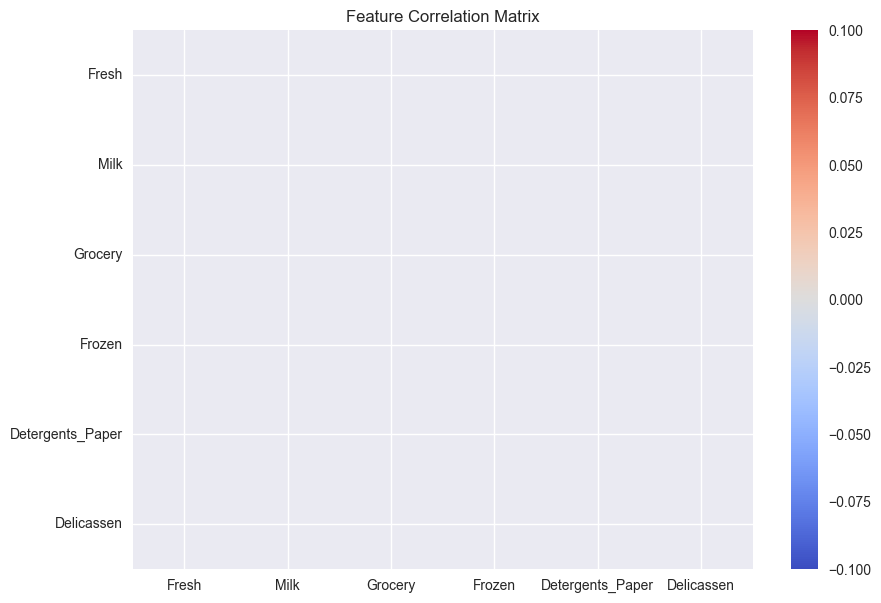

In [21]:
# Correlation analysis

# Check for collinearity.

# ============================================================
# Correlation matrix
# ============================================================

import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(customers_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")

In [26]:
customers = customers.apply(pd.to_numeric, errors="ignore")

In [30]:
# ============================================================
# Convert columns from object → numeric
# ============================================================

customers = customers.apply(pd.to_numeric, errors="coerce")

customers.dtypes

Channel             object
Region              object
Fresh               object
Milk                object
Grocery             object
Frozen              object
Detergents_Paper    object
Delicassen          object
dtype: object

In [31]:
customers.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [32]:
customers.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,0,0,0,0,0,0,0,0
unique,0,0,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
customers = pd.read_sql("SELECT * FROM wholesale_customers_data", engine)

customers.shape

(440, 8)

In [36]:
customers = customers.apply(pd.to_numeric)
customers.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

## Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [37]:
# Your code here
# ============================================================
# Feature Selection
# ============================================================

customers_features = customers.drop(columns=["Channel", "Region"])

customers_features.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [38]:
# Retail spending distributions are heavily right-skewed.

# ============================================================
# Log Transformation
# ============================================================

customers_log = np.log1p(customers_features)

customers_log.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


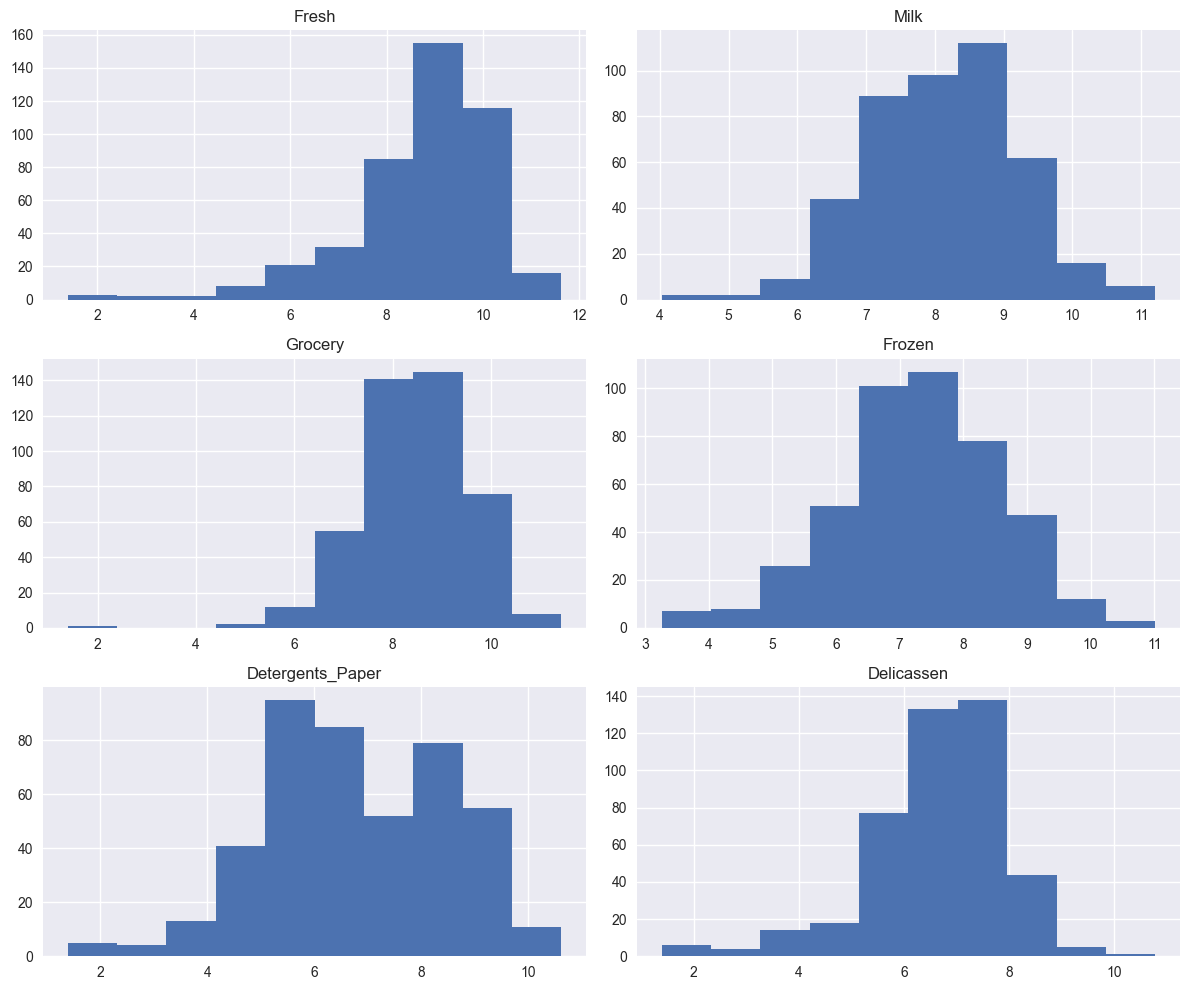

In [39]:
# ============================================================
# Distribution after log transformation
# ============================================================

customers_log.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

customers_scaled = scaler.fit_transform(customers_log)

customers_scaled[:5]

array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339],
       [ 0.51747725, -0.95797283, -0.08479166,  1.14157433, -0.3287115 ,
         0.63313326],
       [ 0.8806309 ,  0.43966195,  0.39584651,  0.75732216,  0.40493851,
         1.4565879 ]])

In [42]:
customers_scaled = pd.DataFrame(
    customers_scaled,
    columns=customers_features.columns
)

customers_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


In [43]:
customers_scaled

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588
...,...,...,...,...,...,...
435,1.066222,1.181548,1.116754,1.702540,-0.926632,0.794891
436,1.255565,-0.791906,-1.623340,0.867791,-1.316771,0.843179
437,0.579528,1.413991,1.688657,-0.953514,1.647619,0.666566
438,0.344609,-0.490783,-0.658498,-0.278901,-0.973241,0.766663


Data transformations was applied

Channel and Region were removed because they represent categorical labels, not purchasing behavior.

A log transformation was applied to spending variables to reduce right-skewed distributions and extreme outliers.

Features were standardized using StandardScaler to ensure equal weighting in distance-based clustering algorithms.

These preprocessing steps really improve the performance and interpretability of clustering models.

## Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [46]:
# Your import here:

from sklearn.preprocessing import StandardScaler

# Your code here:


In [47]:
# ============================================================
# Feature Selection for Scaling
# ============================================================

customers_features = customers.drop(columns=["Channel", "Region"])

In [48]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

customers_scale = scaler.fit_transform(customers_features)

In [49]:
customers_scale = pd.DataFrame(
    customers_scale,
    columns=customers_features.columns
)

customers_scale.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [50]:
customers_scale.describe().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.95,-0.78,-0.84,-0.63,-0.60,-0.54
25%,-0.70,-0.58,-0.61,-0.48,-0.55,-0.40
50%,-0.28,-0.29,-0.34,-0.32,-0.43,-0.20
75%,0.39,0.19,0.28,0.10,0.22,0.10
max,7.93,9.18,8.94,11.92,7.97,16.48


## Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [51]:
# Your code here:
# Import K-Means
from sklearn.cluster import KMeans

In [52]:
# ============================================================
# K-Means Clustering
# ============================================================

kmeans = KMeans(n_clusters=3, random_state=42)

In [53]:
kmeans.fit(customers_scale)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [54]:
labels = kmeans.labels_

In [55]:
customers["labels"] = labels

In [56]:
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,1


In [57]:
# useful quick diagnostic.

customers["labels"].value_counts()

labels
0    350
1     53
2     37
Name: count, dtype: int64

In [58]:
# let's compute average spending per cluster:

customers.groupby("labels").mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,,,
0,1.282857,2.534286,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000
1,1.113208,2.698113,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283
2,2.000000,2.405405,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351


In [59]:
# Clean final block (I love this for the notebook)
# ============================================================
# K-Means Clustering
# ============================================================

from sklearn.cluster import KMeans

# Initialize model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
kmeans.fit(customers_scale)

# Assign cluster labels
customers["labels"] = kmeans.labels_

# Inspect clustering results
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,1


The K-Means algorithm partitions customers into groups based on similarity in their purchasing behavior. Each record receives a cluster label indicating its membership in one of the groups. By attaching the cluster labels to the original dataset, we can analyze how spending patterns differ between clusters.

Count the values in `labels`.

In [60]:
# Your code here:
# ============================================================
# Cluster Size Distribution
# ============================================================

customers["labels"].value_counts()


labels
0    350
1     53
2     37
Name: count, dtype: int64

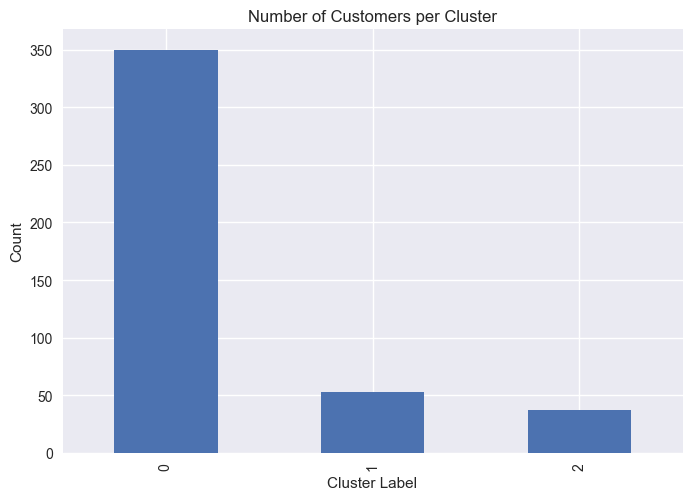

In [61]:
customers["labels"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Count")
plt.show()

Cluster distribution

After applying K-Means clustering, each customer was assigned a cluster label. Counting the labels reveals how many customers belong to each cluster, allowing us to assess whether clusters are balanced or dominated by a single group.

## Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [62]:
# Your code here
# ============================================================
# DBSCAN Clustering
# ============================================================

from sklearn.cluster import DBSCAN

# Initialize model
dbscan = DBSCAN(eps=0.5)

# Fit model
dbscan.fit(customers_scale)

# Assign cluster labels
customers["labels_DBSCAN"] = dbscan.labels_

# Inspect results
customers.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,labels_DBSCAN
0,2,3,12669,9656,7561,214,2674,1338,0,0
1,2,3,7057,9810,9568,1762,3293,1776,0,0
2,2,3,6353,8808,7684,2405,3516,7844,0,-1
3,1,3,13265,1196,4221,6404,507,1788,0,0
4,2,3,22615,5410,7198,3915,1777,5185,1,-1


Count the values in `labels_DBSCAN`.

In [63]:
# Your code here
# ============================================================
# DBSCAN Cluster Size Distribution
# ============================================================

customers["labels_DBSCAN"].value_counts()


labels_DBSCAN
 0    261
-1    174
 1      5
Name: count, dtype: int64

In [65]:
# NOISE CLUSTER FIRST
customers["labels_DBSCAN"].value_counts().sort_index()

labels_DBSCAN
-1    174
 0    261
 1      5
Name: count, dtype: int64

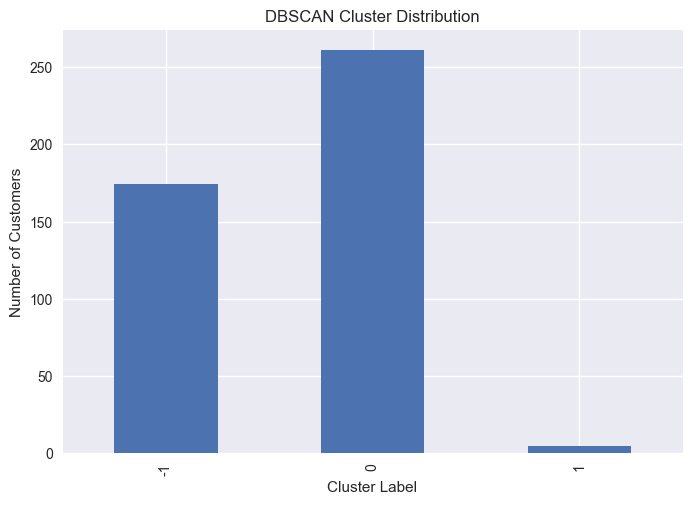

In [66]:
customers["labels_DBSCAN"].value_counts().sort_index().plot(kind="bar")

plt.title("DBSCAN Cluster Distribution")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")
plt.show()

## Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [67]:
# Your code here:
import seaborn as sns


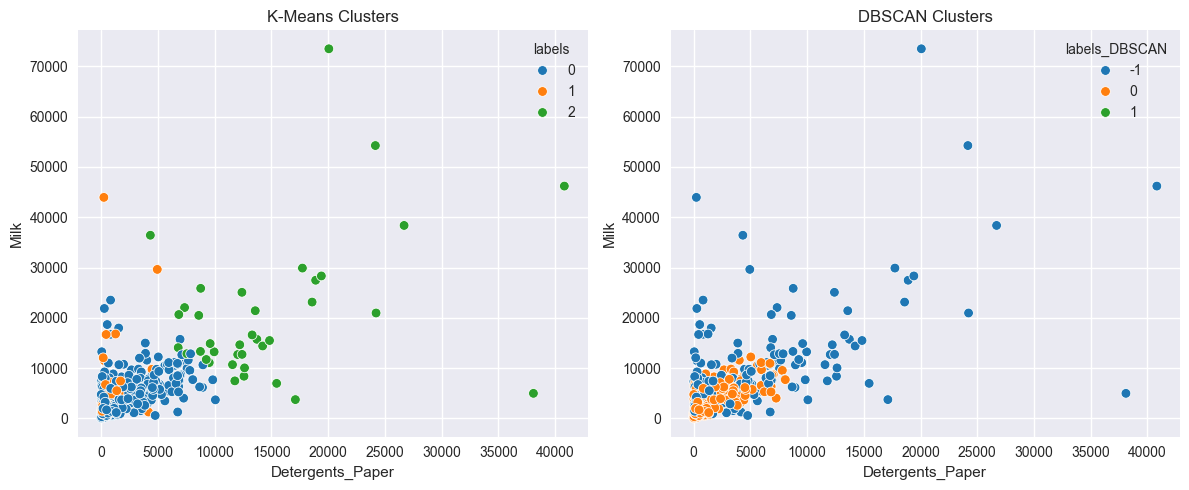

In [68]:
# ============================================================
# Cluster Comparison: Detergents_Paper vs Milk
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=customers,
    x="Detergents_Paper",
    y="Milk",
    hue="labels",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")

sns.scatterplot(
    data=customers,
    x="Detergents_Paper",
    y="Milk",
    hue="labels_DBSCAN",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")

plt.tight_layout()
plt.show()

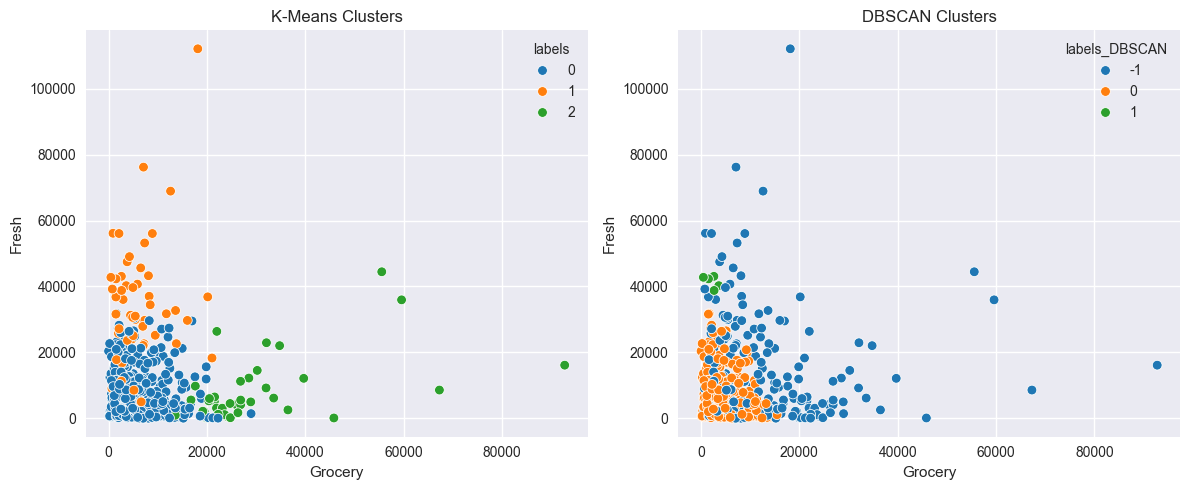

In [69]:
# ============================================================
# Cluster Comparison: Grocery vs Fresh
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=customers,
    x="Grocery",
    y="Fresh",
    hue="labels",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")

sns.scatterplot(
    data=customers,
    x="Grocery",
    y="Fresh",
    hue="labels_DBSCAN",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")

plt.tight_layout()
plt.show()

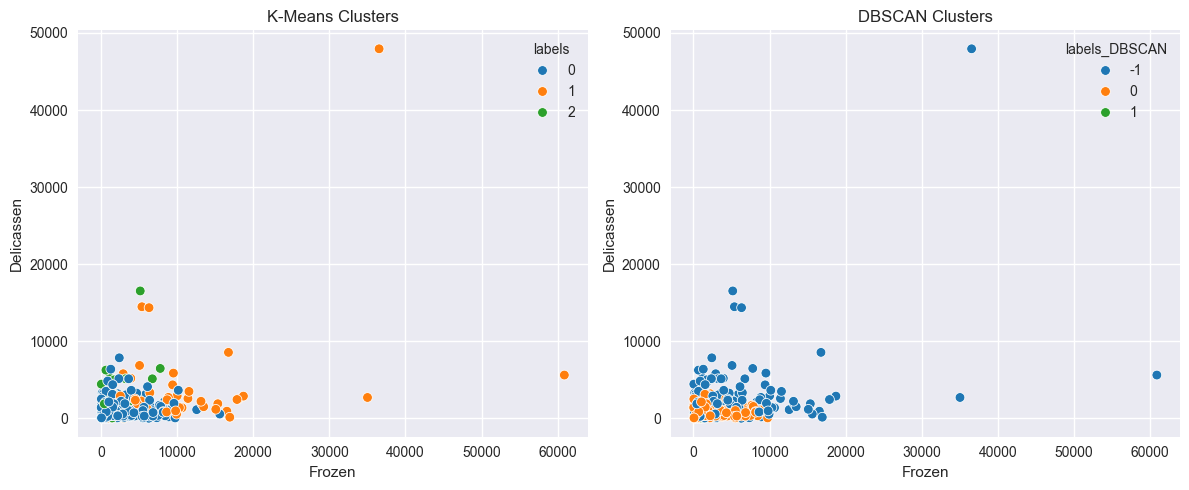

In [70]:
# ============================================================
# Cluster Comparison: Frozen vs Delicassen
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=customers,
    x="Frozen",
    y="Delicassen",
    hue="labels",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")

sns.scatterplot(
    data=customers,
    x="Frozen",
    y="Delicassen",
    hue="labels_DBSCAN",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")

plt.tight_layout()
plt.show()

The scatter plots reveal that K-Means produces clearer cluster separation across several feature pairs. DBSCAN identifies some noise points but does not form well-defined clusters for this dataset using the default eps=0.5. Therefore, K-Means appears to provide more interpretable segmentation of customer purchasing behavior.

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

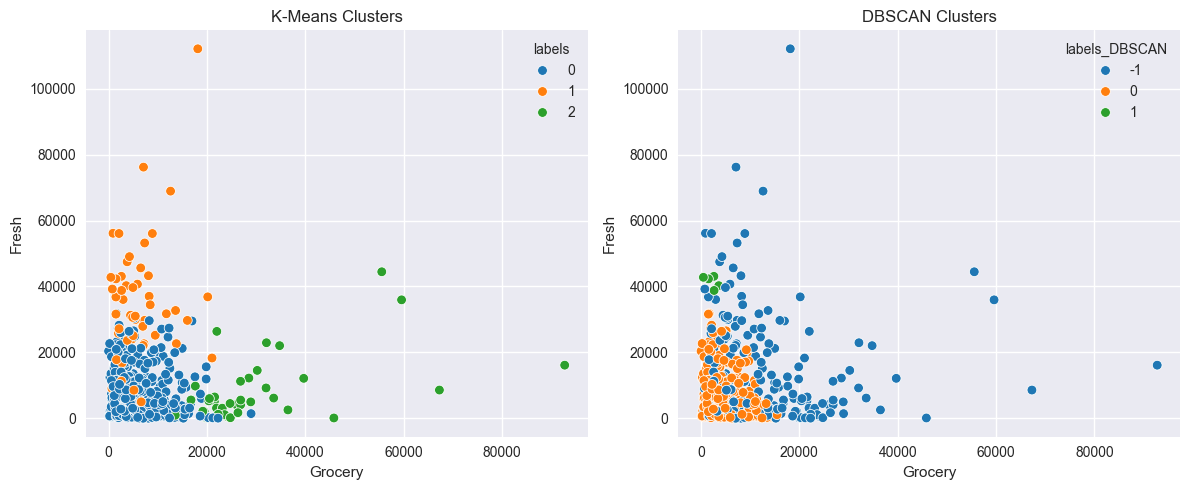

In [71]:
# Your code here:
# ============================================================
# Cluster Comparison: Grocery vs Fresh
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# K-Means clustering
sns.scatterplot(
    data=customers,
    x="Grocery",
    y="Fresh",
    hue="labels",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Grocery")
axes[0].set_ylabel("Fresh")

# DBSCAN clustering
sns.scatterplot(
    data=customers,
    x="Grocery",
    y="Fresh",
    hue="labels_DBSCAN",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")
axes[1].set_xlabel("Grocery")
axes[1].set_ylabel("Fresh")

plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

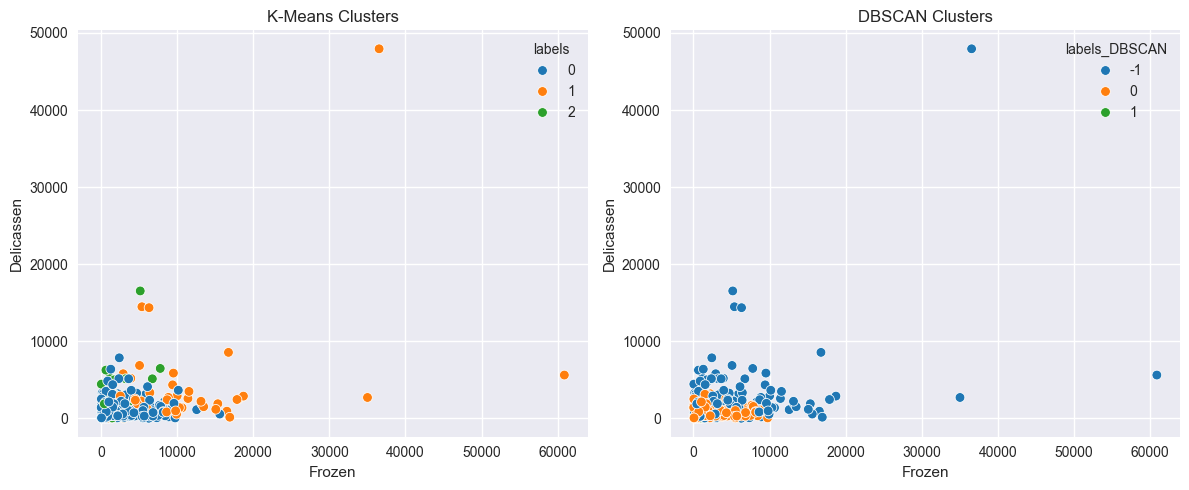

In [72]:
# Your code here:
# ============================================================
# Cluster Comparison: Frozen vs Delicassen
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# K-Means clustering
sns.scatterplot(
    data=customers,
    x="Frozen",
    y="Delicassen",
    hue="labels",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Frozen")
axes[0].set_ylabel("Delicassen")

# DBSCAN clustering
sns.scatterplot(
    data=customers,
    x="Frozen",
    y="Delicassen",
    hue="labels_DBSCAN",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")
axes[1].set_xlabel("Frozen")
axes[1].set_ylabel("Delicassen")

plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [73]:
# Your code here:
# ============================================================
# Cluster profile using K-Means labels
# ============================================================

customers.groupby("labels").mean()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels_DBSCAN
labels,,,,,,,,,
0,1.282857,2.534286,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000,-0.257143
1,1.113208,2.698113,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283,-0.792453
2,2.000000,2.405405,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351,-1.000000


In [74]:
# ============================================================
# Cluster profile using DBSCAN labels
# ============================================================

customers.groupby("labels_DBSCAN").mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
labels_DBSCAN,,,,,,,,,
-1,1.522989,2.551724,15608.988506,10000.408046,13693.298851,4786.275862,5291.373563,2510.781609,0.695402
0,1.195402,2.528736,9030.398467,3077.318008,4234.061303,1963.432950,1322.134100,881.773946,0.003831
1,1.000000,3.000000,41446.600000,1421.200000,2167.600000,1276.400000,416.200000,784.800000,1.000000


In [75]:
customers.groupby("labels").mean().sort_index()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels_DBSCAN
labels,,,,,,,,,
0,1.282857,2.534286,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000,-0.257143
1,1.113208,2.698113,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283,-0.792453
2,2.000000,2.405405,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351,-1.000000


In [76]:
customers.groupby("labels_DBSCAN").mean().sort_index()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
labels_DBSCAN,,,,,,,,,
-1,1.522989,2.551724,15608.988506,10000.408046,13693.298851,4786.275862,5291.373563,2510.781609,0.695402
0,1.195402,2.528736,9030.398467,3077.318008,4234.061303,1963.432950,1322.134100,881.773946,0.003831
1,1.000000,3.000000,41446.600000,1421.200000,2167.600000,1276.400000,416.200000,784.800000,1.000000


In [77]:
# round the values so the table is as tidy as Nana's House
customers.groupby("labels").mean().round(2)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels_DBSCAN
labels,,,,,,,,,
0,1.28,2.53,8935.50,4228.53,5848.03,2167.23,1913.61,1102.12,-0.26
1,1.11,2.70,34540.11,5860.36,6122.62,9841.74,981.47,3664.25,-0.79
2,2.00,2.41,8704.86,20534.41,30466.24,1932.62,14758.84,2459.35,-1.00


Which algorithm appears to perform better?

K-Means appears to perform better for this dataset. The algorithm produces clearer and more balanced clusters, allowing meaningful segmentation of customers based on spending behavior. In contrast, DBSCAN identifies many observations as noise with the selected eps parameter and produces fewer interpretable clusters. Therefore, K-Means provides more useful results for customer segmentation in this case.

In [78]:
# Your observations here
# K-Means appears to perform better for this dataset. The algorithm produces clearer and more balanced clusters, allowing 
# meaningful segmentation of customers based on spending behavior. In contrast, DBSCAN identifies many observations as noise 
# with the selected eps parameter and produces fewer interpretable clusters. Therefore, K-Means provides more useful results for 
# customer segmentation in this case.
    

## Bonus Challenge 1 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [79]:
from sklearn.cluster import KMeans

# ============================================================
# Test different numbers of clusters
# ============================================================

k_values = [2, 3, 4, 5, 6]

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    customers[f"labels_k{k}"] = kmeans.fit_predict(customers_scale)

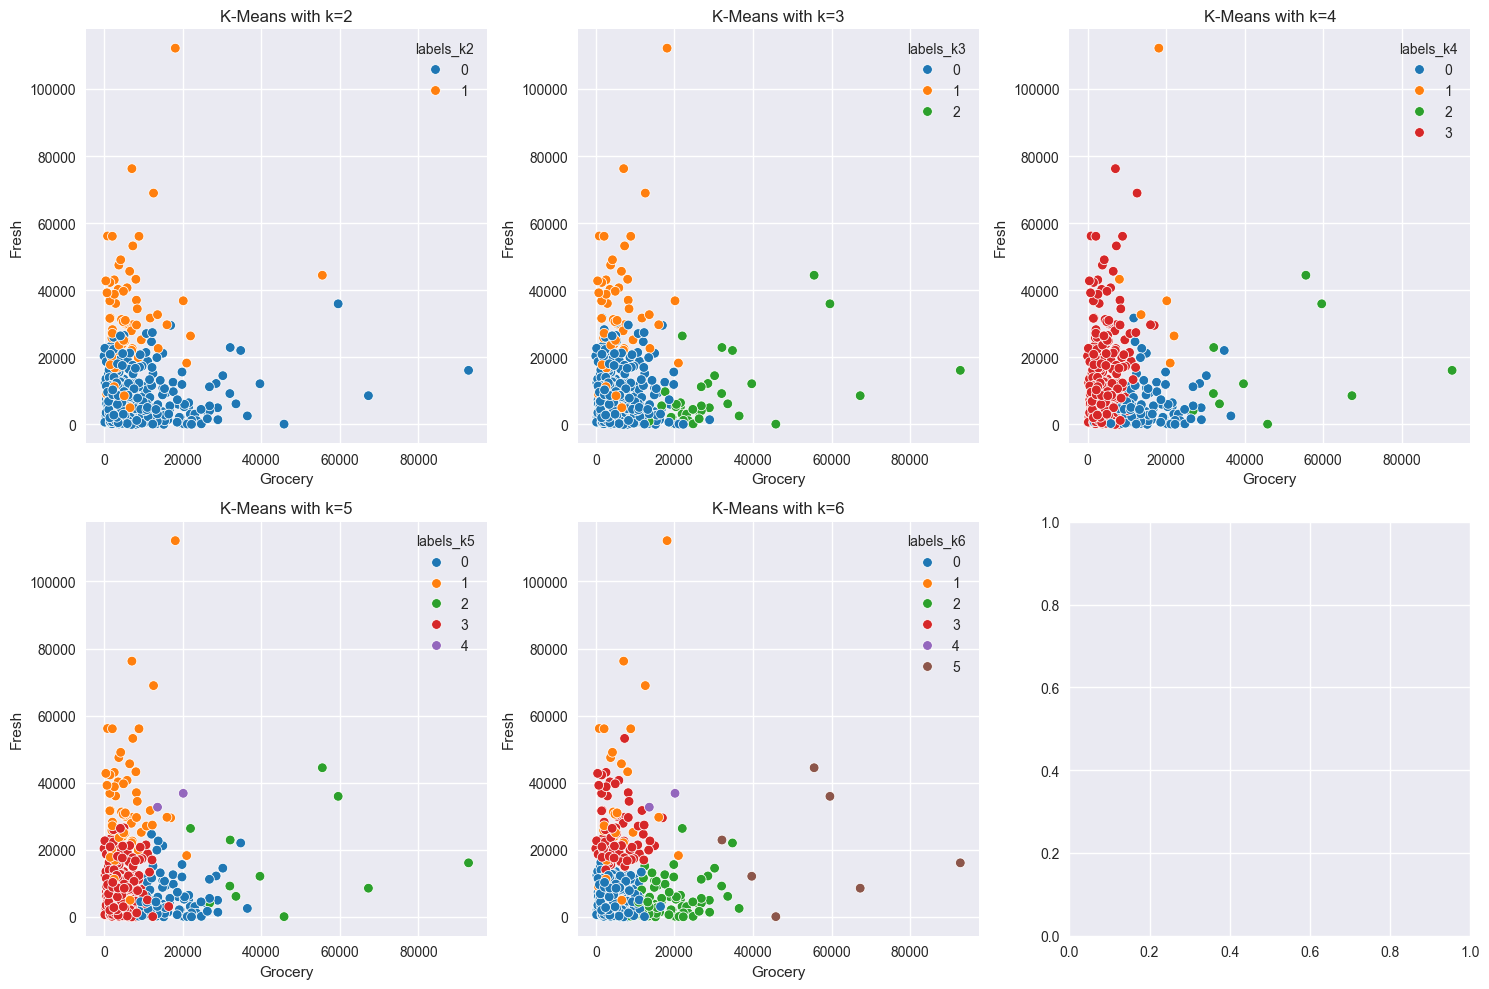

In [80]:
# Your code here
fig, axes = plt.subplots(2, 3, figsize=(15,10))

k_values = [2, 3, 4, 5, 6]

for i, k in enumerate(k_values):
    
    ax = axes.flatten()[i]
    
    sns.scatterplot(
        data=customers,
        x="Grocery",
        y="Fresh",
        hue=f"labels_k{k}",
        palette="tab10",
        ax=ax
    )
    
    ax.set_title(f"K-Means with k={k}")

plt.tight_layout()
plt.show()

By visually comparing cluster plots for several values of k, three clusters appear to produce the most meaningful segmentation of customers. Lower values merge distinct spending patterns, while higher values fragment the data into smaller groups without clear separation. Therefore, k = 3 appears to be the most appropriate number of clusters for this dataset.

In [18]:
# Your comment here

## Bonus Challenge 2 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [81]:
# Your code here
from sklearn.cluster import DBSCAN

# ============================================================
# DBSCAN Parameter Experiment
# ============================================================

configs = [
    (0.3, 5),
    (0.5, 5),
    (0.8, 10)
]

for eps, min_samples in configs:
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    
    customers[f"dbscan_eps{eps}_min{min_samples}"] = dbscan.fit_predict(customers_scale)

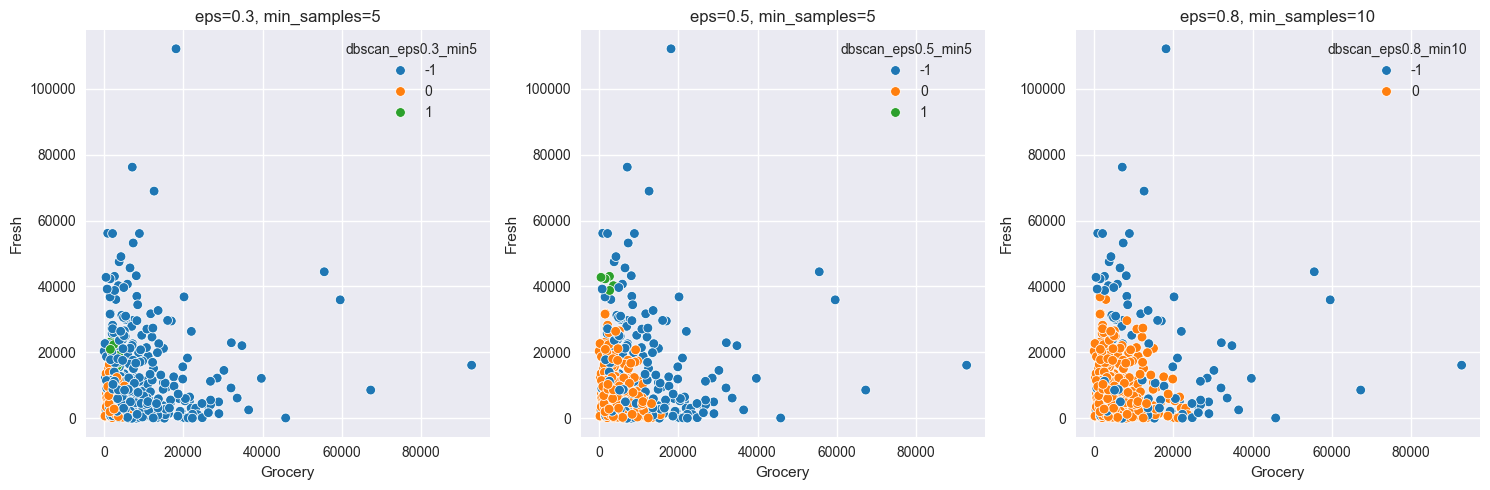

In [82]:
# Your comment here
fig, axes = plt.subplots(1, 3, figsize=(15,5))

configs = [
    (0.3, 5),
    (0.5, 5),
    (0.8, 10)
]

for i, (eps, min_samples) in enumerate(configs):
    
    sns.scatterplot(
        data=customers,
        x="Grocery",
        y="Fresh",
        hue=f"dbscan_eps{eps}_min{min_samples}",
        palette="tab10",
        ax=axes[i]
    )
    
    axes[i].set_title(f"eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.show()

INTERESTING!
Changing the DBSCAN parameters significantly affects the clustering results. Lower eps values produce stricter density requirements and classify many observations as noise, while larger eps values merge more points into clusters. Adjusting min_samples also influences how dense a region must be to form a cluster. These results illustrate that DBSCAN requires careful parameter tuning to produce meaningful clusters.